# `find_surface_pores`
Locates clusters of void voxels that touch a surface but do not span the domain between opposite faces.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.find_surface_pores)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], axis: int = None, conn: Literal['max', 'min'] = 'min')>

## `im`
A boolean image with `True` indicating the void phase. By default surface pores are clusters that touch *some* face but not opposite faces in any direction.

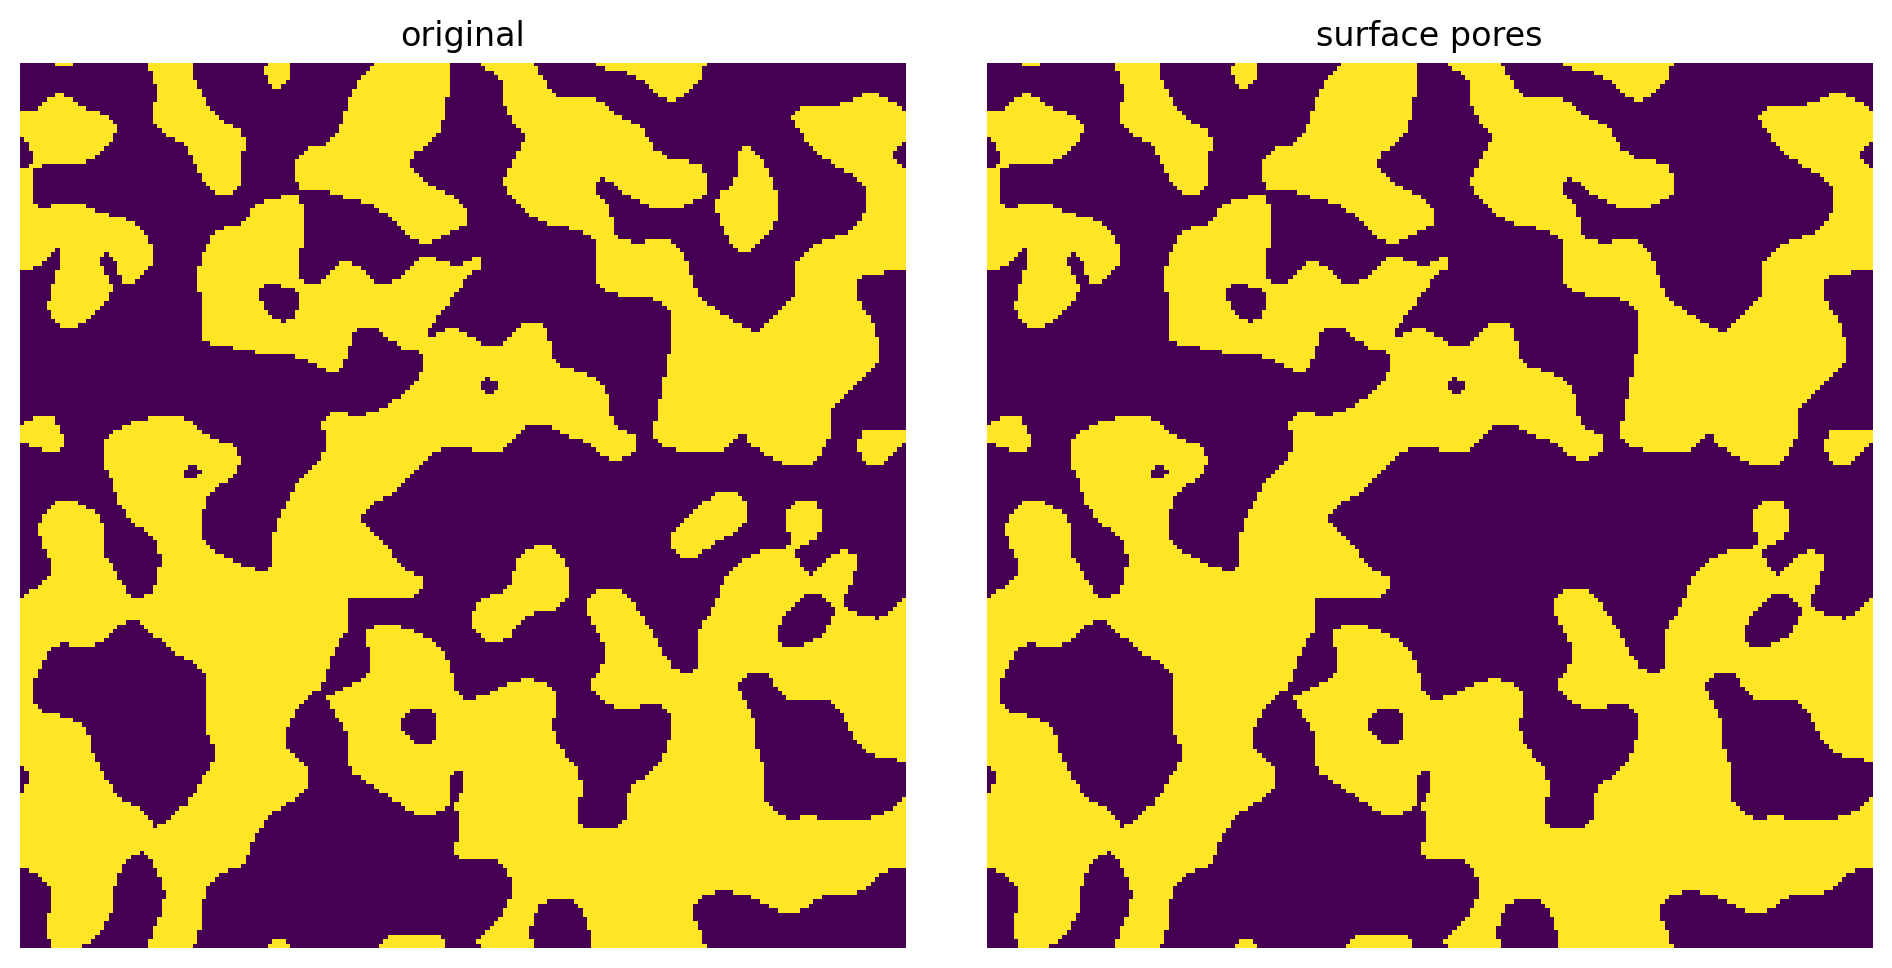

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.5, seed=0)
surf = ps.filters.find_surface_pores(im=im)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(im, origin='lower', interpolation='none')
ax[0].set_title('original')
ax[0].axis(False)
ax[1].imshow(surf, origin='lower', interpolation='none')
ax[1].set_title('surface pores')
ax[1].axis(False);

## `axis`
Restricts the test to a single direction. With `axis=0` a cluster is considered spanning only if it touches both `im[0, ...]` and `im[-1, ...]`; clusters that touch a face but do not span are flagged as surface pores.

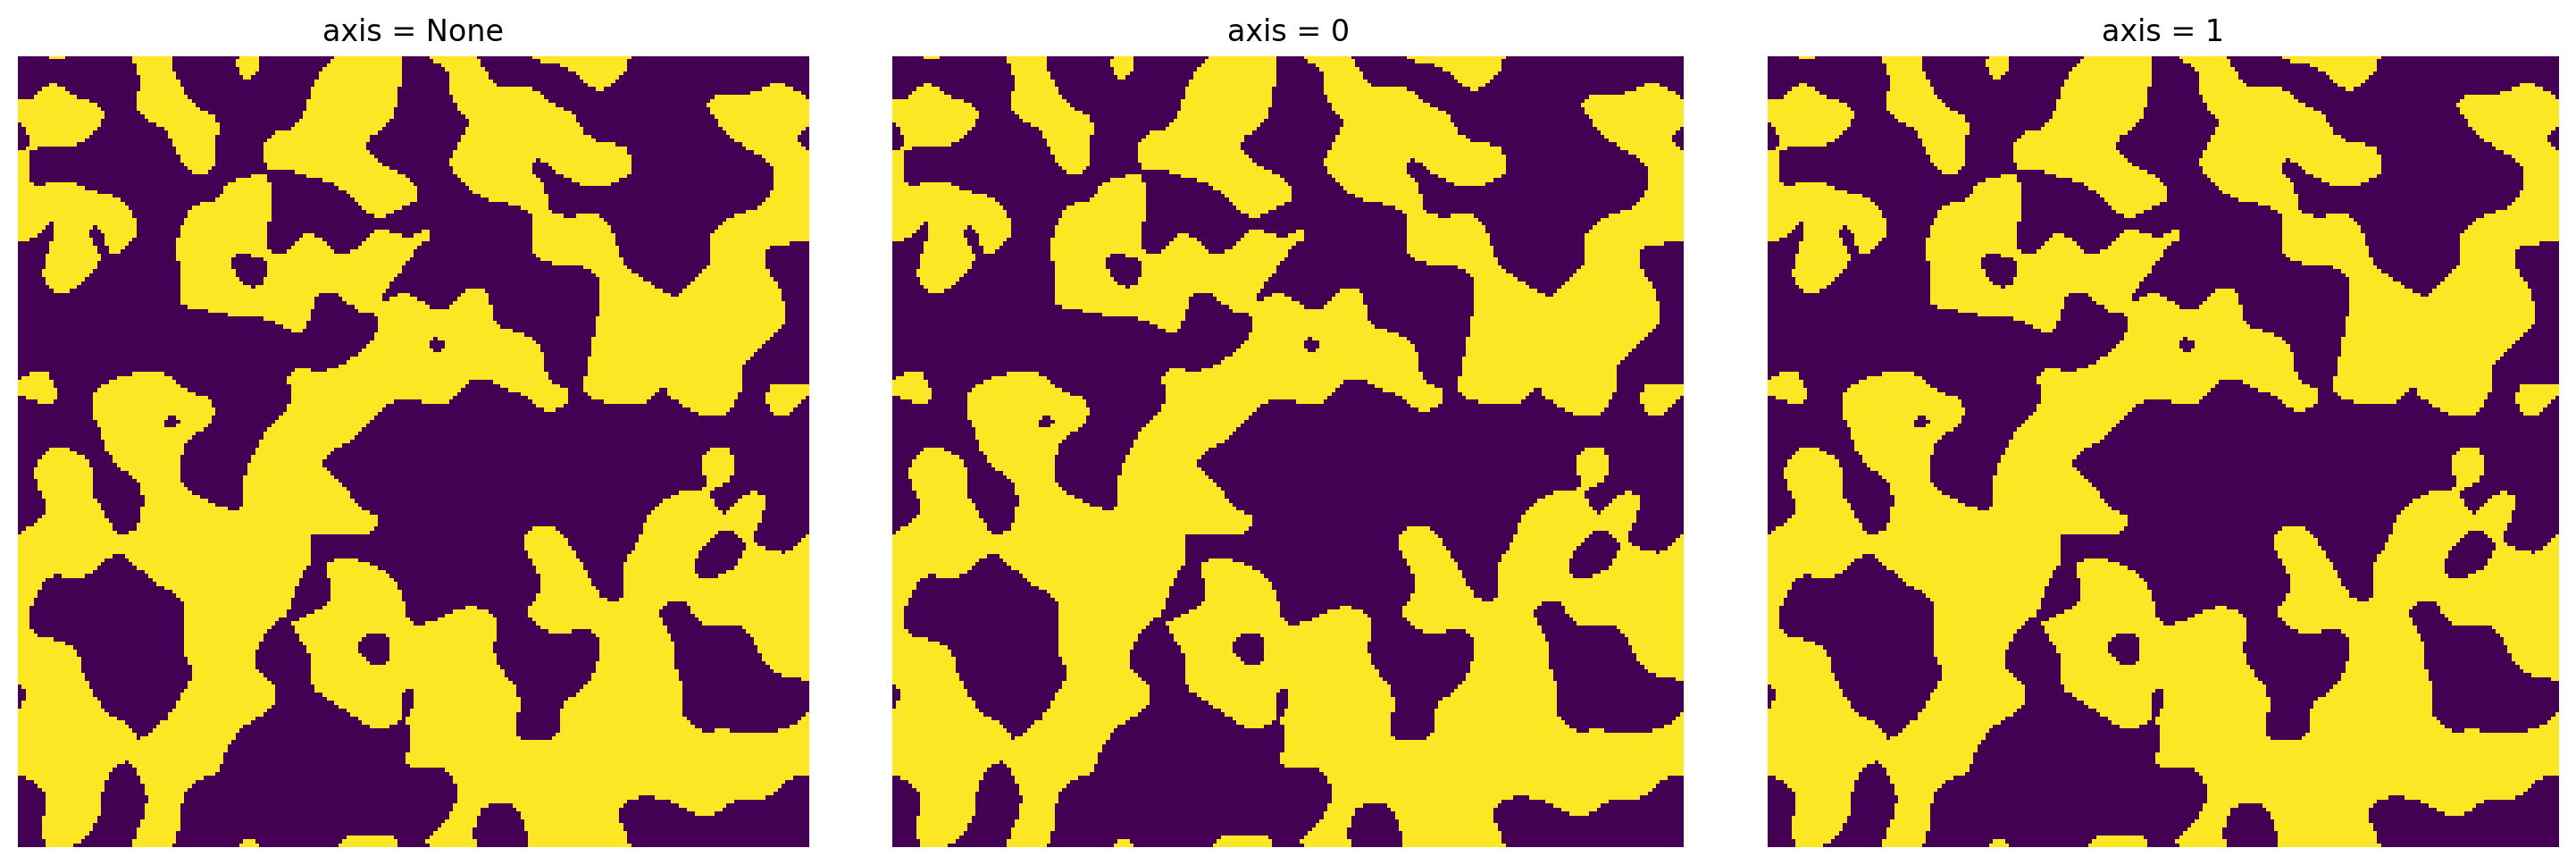

In [4]:
surf_all = ps.filters.find_surface_pores(im=im)
surf_x = ps.filters.find_surface_pores(im=im, axis=0)
surf_y = ps.filters.find_surface_pores(im=im, axis=1)

fig, ax = plt.subplots(1, 3, figsize=[15, 5])
ax[0].imshow(surf_all, origin='lower', interpolation='none')
ax[0].set_title('axis = None')
ax[0].axis(False)
ax[1].imshow(surf_x, origin='lower', interpolation='none')
ax[1].set_title('axis = 0')
ax[1].axis(False)
ax[2].imshow(surf_y, origin='lower', interpolation='none')
ax[2].set_title('axis = 1')
ax[2].axis(False);

## `conn`
Controls voxel connectivity. `'min'` (default) means voxels must share a face to be connected; `'max'` also accepts edges and corners.

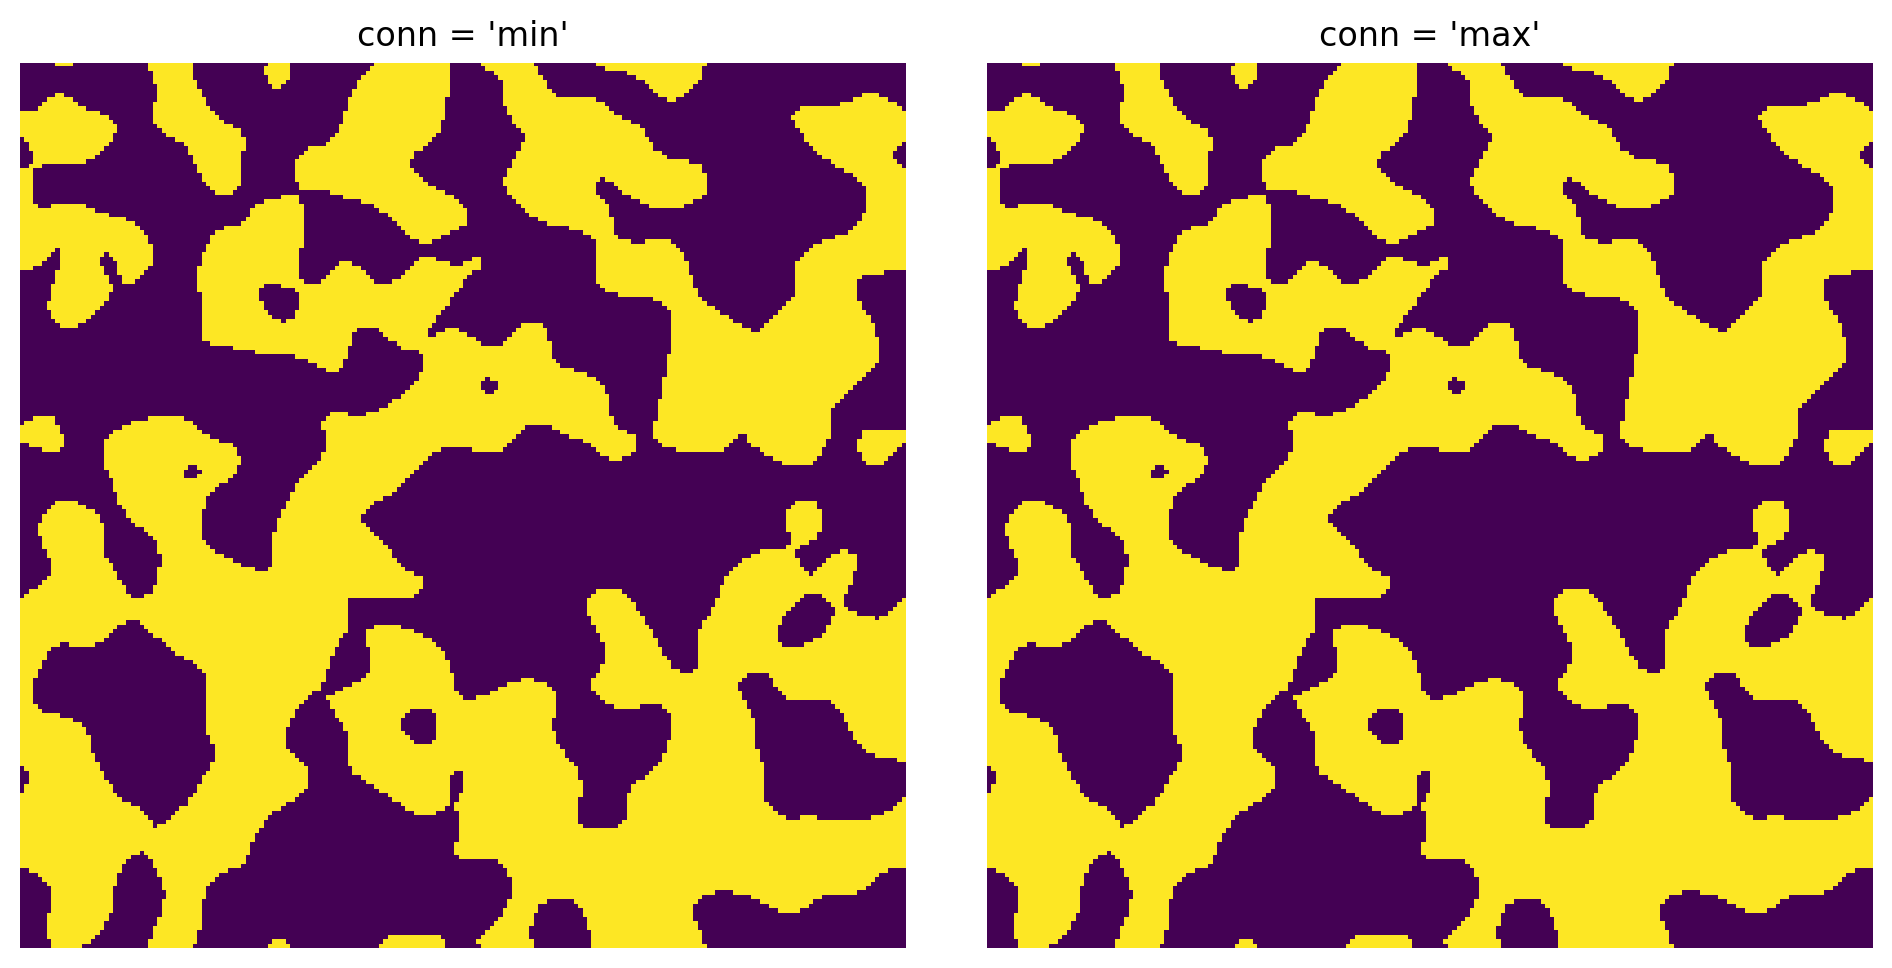

In [5]:
surf_min = ps.filters.find_surface_pores(im=im, conn='min')
surf_max = ps.filters.find_surface_pores(im=im, conn='max')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(surf_min, origin='lower', interpolation='none')
ax[0].set_title("conn = 'min'")
ax[0].axis(False)
ax[1].imshow(surf_max, origin='lower', interpolation='none')
ax[1].set_title("conn = 'max'")
ax[1].axis(False);